In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Import plotting functions from graphs.py
from graphs import (
    load_runs,
    plot_requests_per_second,
    plot_batch_times,
    get_requests_per_second,
    _batch_elapsed,
    _build_color_map,
    _collect_model_names,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration
Select which runs and baselines to load, and toggle display options.

In [31]:
# Directories
BASELINES_DIR = Path("baselines")
RUNS_DIR = Path("runs")

# Display options
INCLUDE_REBALANCE_TIME = False  # include rebalance time in elapsed calculations
SHOW_REBALANCE = False          # show vertical rebalance event lines
SHOW_OPTIMUM = True             # show optimum markers

# Filter runs and baselines (set to None to load all, or a list like ["run20", "run21"])
SELECTED_RUNS = ['run22', 'run23']
SELECTED_BASELINES = ['tensor_parallel', 'gpipe_4x8']

In [32]:
# Load data
all_baselines = load_runs(BASELINES_DIR)
all_runs = load_runs(RUNS_DIR)

if SELECTED_RUNS is not None:
    runs = {k: v for k, v in all_runs.items() if k in SELECTED_RUNS}
else:
    runs = all_runs

if SELECTED_BASELINES is not None:
    baselines = {k: v for k, v in all_baselines.items() if k in SELECTED_BASELINES}
else:
    baselines = all_baselines

print(f"Loaded {len(baselines)} baselines: {list(baselines.keys())}")
print(f"Loaded {len(runs)} runs: {list(runs.keys())}")

Loaded 2 baselines: ['gpipe_4x8', 'tensor_parallel']
Loaded 2 runs: ['run22', 'run23']


## Throughput (Requests per Second)

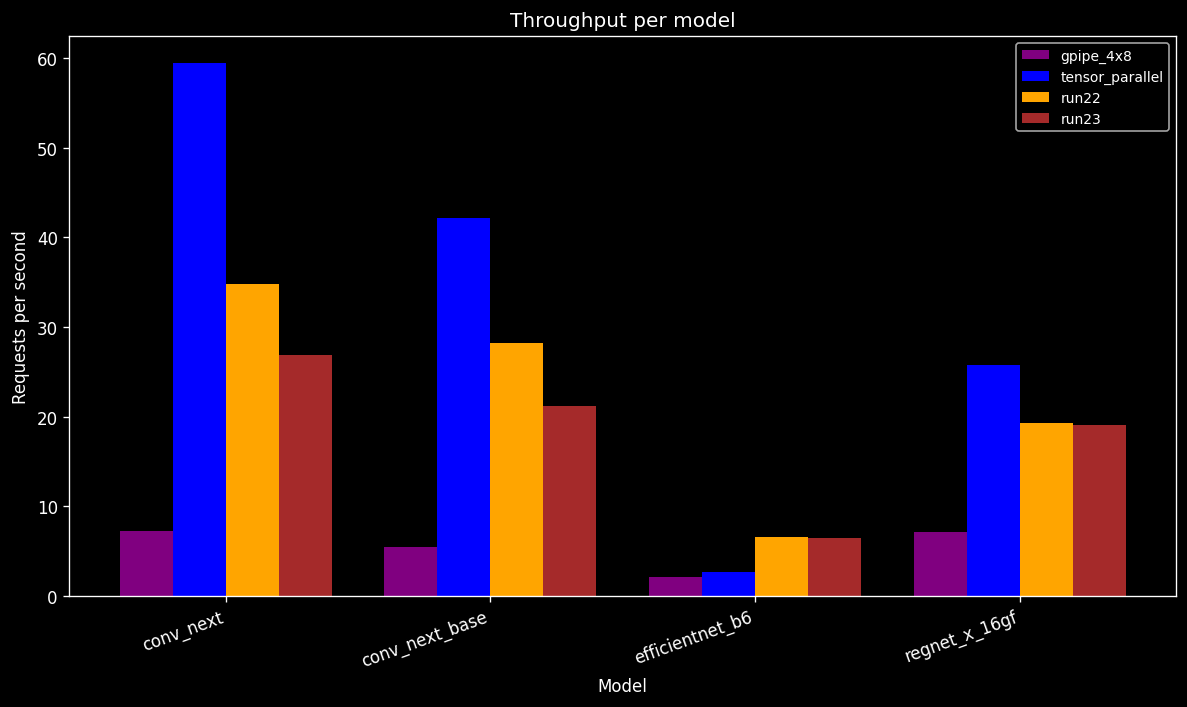

In [33]:
plot_requests_per_second(baselines, runs, include_rebalance=INCLUDE_REBALANCE_TIME)

## Batch Times

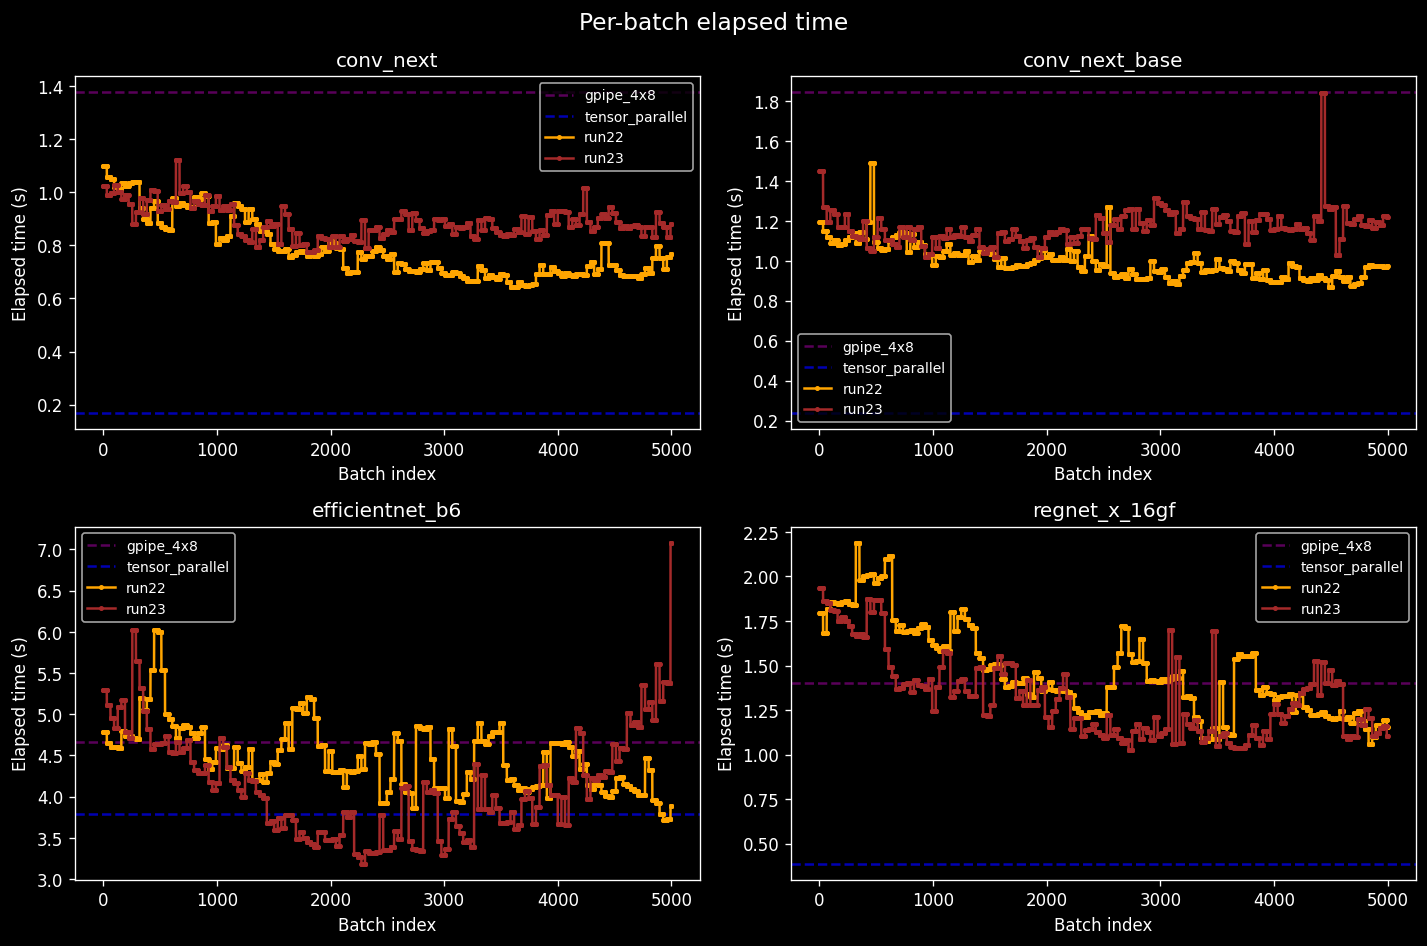

In [34]:
plot_batch_times(
    baselines, runs,
    show_rebalance=SHOW_REBALANCE,
    include_rebalance=INCLUDE_REBALANCE_TIME,
    show_optimum=SHOW_OPTIMUM,
)

## Run Summary Table

In [35]:
for run_name, run_data in sorted(runs.items()):
    meta = run_data.get("meta", {})
    commit = meta.get("git_commit", "?")[:8]
    argv = " ".join(meta.get("argv", [])[1:])
    print(f"=== {run_name} === commit: {commit}")
    print(f"  args: {argv[:100]}")
    for model, result in run_data["results"].items():
        batches = result.get("batches", [])
        rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
        at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
        rps = result.get("requests_per_second", 0)
        print(f"  {model}: rps={rps:.2f}, rebalances={rebalances}, at_optimum={at_optimum}")
    print()

=== run22 === commit: f87dc3b2
  args: -n 5000 -b 1 -m 32 --optimizer shisha --rebalance-interval 10 -o ./data/runs
  conv_next: rps=34.85, rebalances=480, at_optimum=0
  conv_next_base: rps=28.24, rebalances=480, at_optimum=0
  efficientnet_b6: rps=6.60, rebalances=480, at_optimum=0
  regnet_x_16gf: rps=19.25, rebalances=480, at_optimum=0

=== run23 === commit: c7408b13
  args: -n 5000 -b 1 -m 32 --optimizer shisha --rebalance-interval 4 -o ./data/runs
  conv_next: rps=26.86, rebalances=1248, at_optimum=0
  conv_next_base: rps=21.14, rebalances=1248, at_optimum=0
  efficientnet_b6: rps=6.45, rebalances=1248, at_optimum=0
  regnet_x_16gf: rps=19.07, rebalances=1248, at_optimum=0



## Optimizer State Over Time
Plot deep_gamma and sibling_gamma for runs that include optimizer state data.

/var/folders/vy/lwlq37ks1yb9bgyr6cpw86xh0000gn/T/ipykernel_51540/3626502939.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize="small")


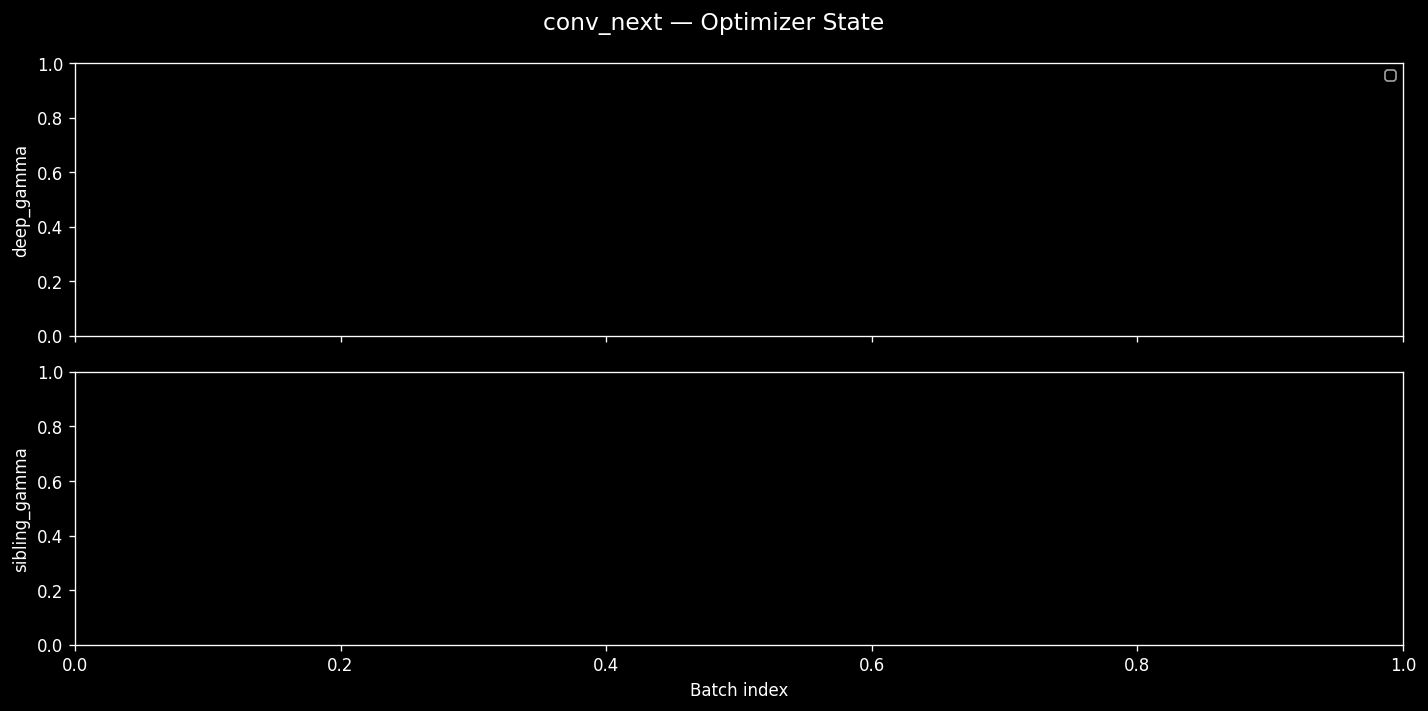

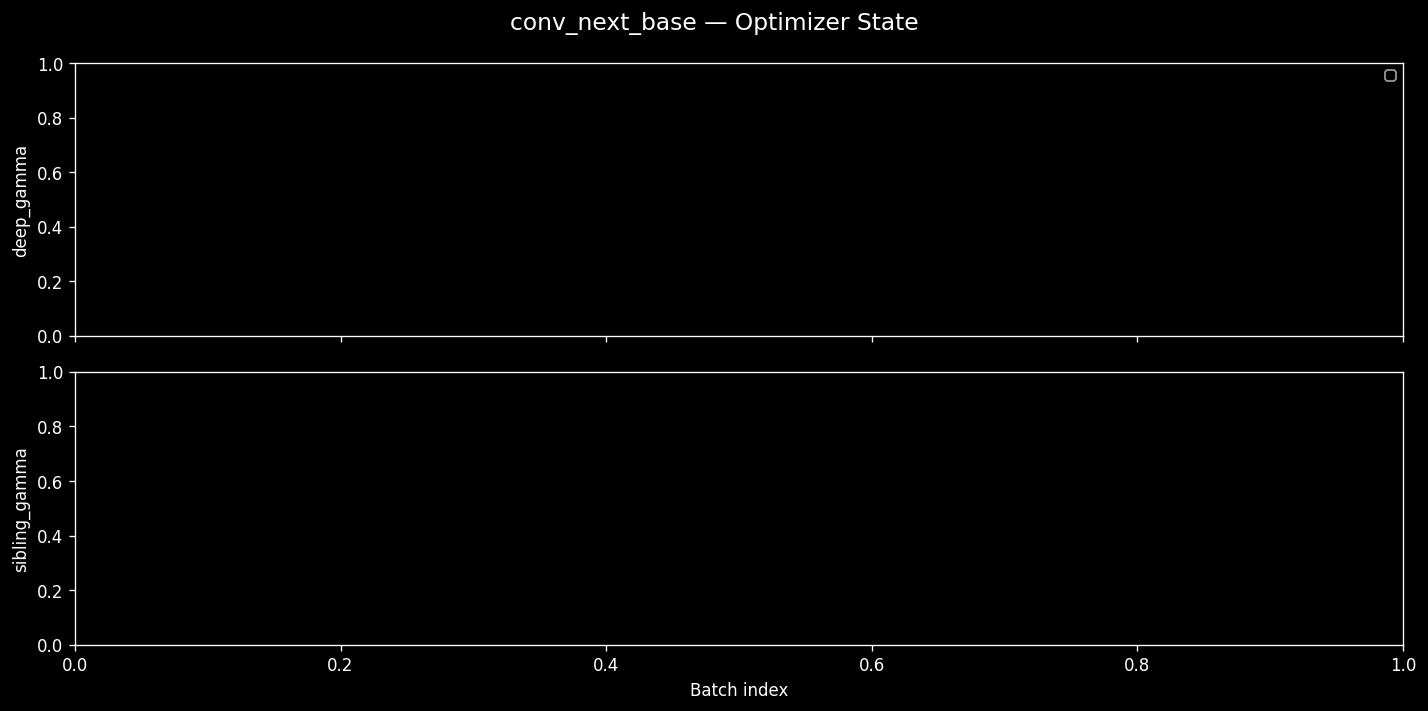

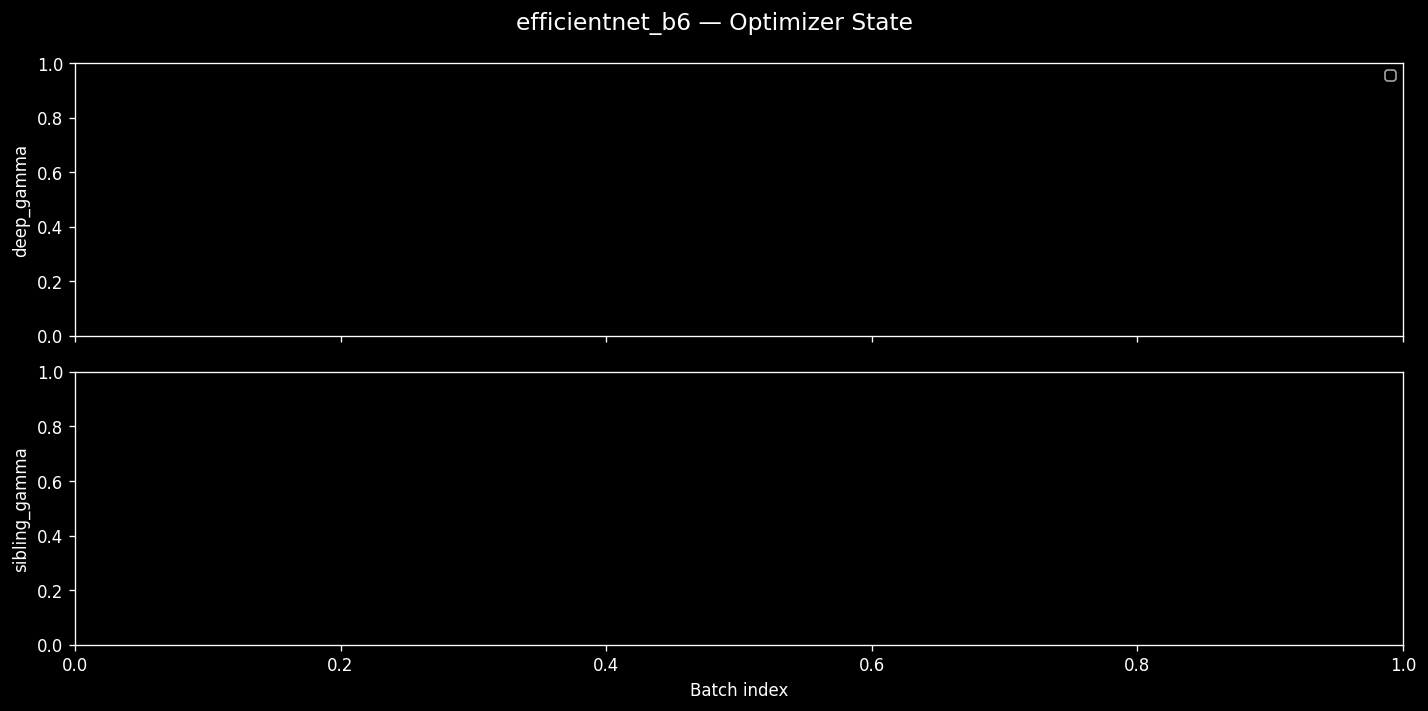

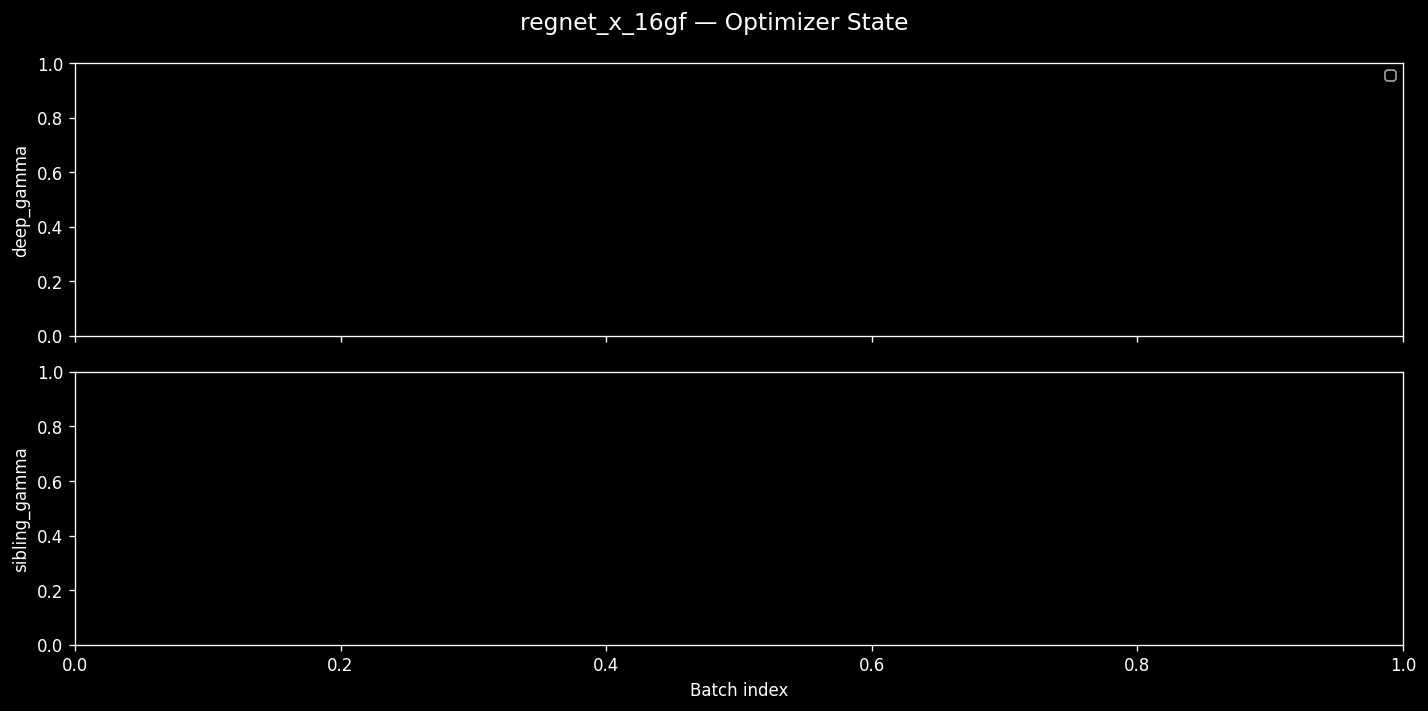

In [28]:
model_names = _collect_model_names(baselines, runs)
colors = _build_color_map(baselines, runs)

for model in model_names:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f"{model} — Optimizer State", fontsize=14)

    for run_name, run_data in runs.items():
        if model not in run_data["results"]:
            continue
        batches = run_data["results"][model].get("batches", [])
        deep_gamma = [b.get("rebalance", {}).get("deep_gamma") for b in batches]
        sibling_gamma = [b.get("rebalance", {}).get("sibling_gamma") for b in batches]

        # Only plot if data exists
        if not any(v is not None for v in deep_gamma):
            continue

        xs = range(len(batches))
        color = colors.get(run_name, "white")
        ax1.plot(xs, deep_gamma, color=color, label=run_name, alpha=0.8, markersize=2)
        ax2.plot(xs, sibling_gamma, color=color, label=run_name, alpha=0.8, markersize=2)

    ax1.set_ylabel("deep_gamma")
    ax1.legend(fontsize="small")
    ax2.set_ylabel("sibling_gamma")
    ax2.set_xlabel("Batch index")
    fig.tight_layout()
    plt.show()